In [50]:
# Import necessary libraries
import pandas
import torch
import numpy as np
import random
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, Matern, RationalQuadratic
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import pandas as pd    

# Set a fixed random state for reproducibility across all random operations
random_state = 42

# Set the path to the dataset
data_path = "../data/TrainingData.csv"

## Data Pre-Processing

In [51]:
# Load the dataset, including missing headers and assigning column names
df = pd.read_csv(data_path, header=None, names=['W1', 'W2', 'R', 't', 'stress'])

# Display basic information about the dataset
sep = '-' * 100
for section in [df.head(), df.shape, df.describe()]:
    print(sep)
    print(section)
print(sep)
df.info()

----------------------------------------------------------------------------------------------------
         W1        W2         R         t     stress
0  0.582950  0.107011  0.069374  0.011457  46.518344
1  0.369159  0.149933  0.035845  0.015876  64.191560
2  0.604024  0.116061  0.039592  0.018931  34.929668
3  0.346207  0.121982  0.046125  0.014213  54.444952
4  0.358780  0.146316  0.030862  0.016575  64.447268
----------------------------------------------------------------------------------------------------
(50, 5)
----------------------------------------------------------------------------------------------------
              W1         W2          R          t     stress
count  50.000000  50.000000  50.000000  50.000000  50.000000
mean    0.500107   0.124957   0.050005   0.014990  48.068301
std     0.116628   0.014626   0.011624   0.002920   9.882066
min     0.303432   0.100323   0.030657   0.010102  31.330892
25%     0.400585   0.112721   0.040231   0.012515  40.076991
50%  

## GPR Model

/opt/anaconda3/envs/data-driven/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 18 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)



=== Kernel Comparison Summary ===
Kernel           CV MAPE (%)    Test RMSE     Test MAE  Test MAPE (%)  Train (s)  Pred (ms)
RBF                   2.6757       1.2694       0.9151         1.8971      0.234     0.0716
Matern_1.5            1.3547       0.5052       0.4404         0.9981      0.157     0.1185
Matern_2.5            1.3657       0.6328       0.5400         1.1755      0.193     0.0435
Quadratic             1.7970       0.7235       0.5681         1.1813      0.332     0.6128

Best kernel by CV MAPE: Matern_1.5
  Training time : 0.157 s
  Prediction time: 0.1185 ms/sample  (vs FEA ~23,000 ms — 194025× speed-up)


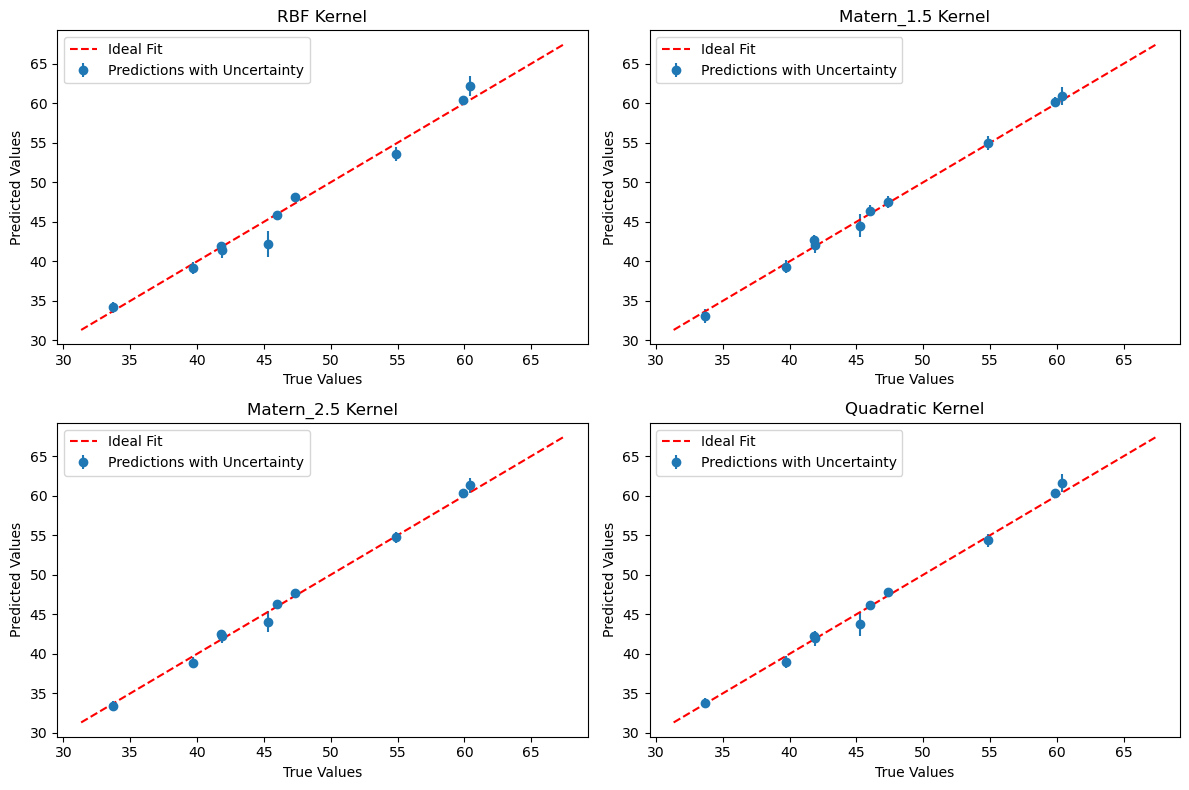

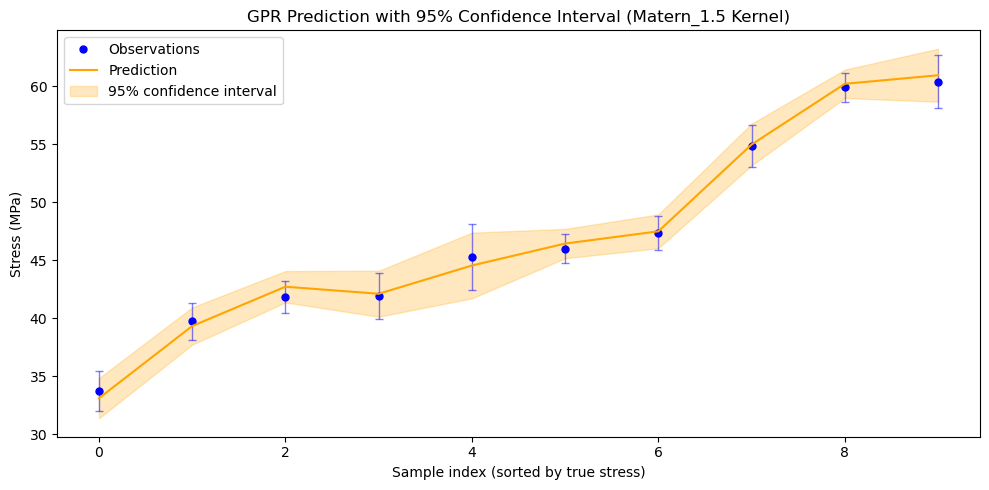

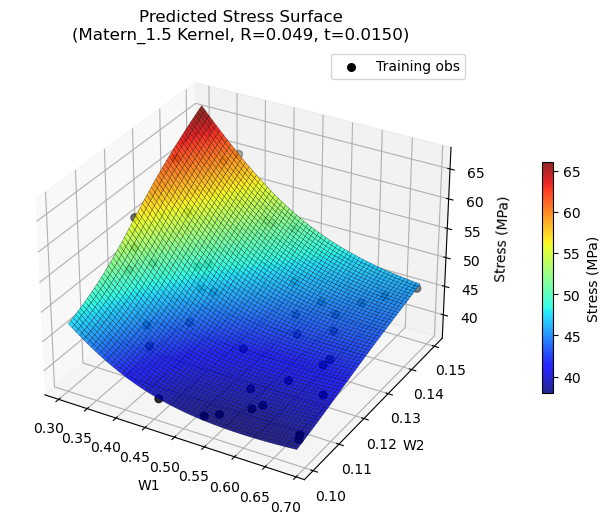

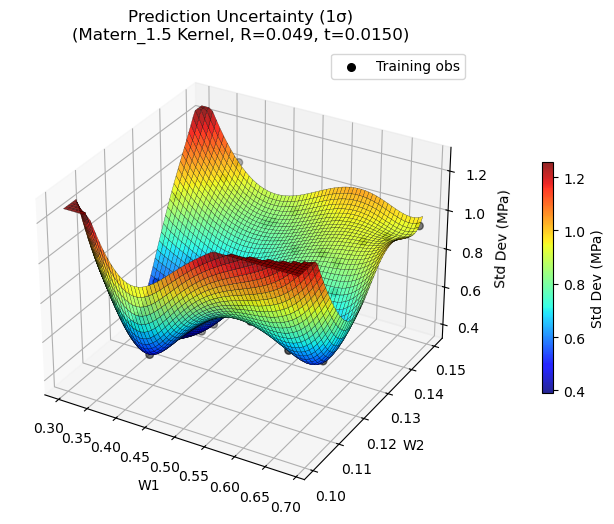

In [52]:
# --- Kernel Dictionary for Comparision ---
# length: length scale — controls rate of change (small=rapid, large=smooth)
# alpha: RationalQuadratic shape — weighting across length scales (small=flexible, large=rigid)
# nu: Matern smoothness — correlation decay rate (small=flexible, large=smooth), higher nu values lead to smoother functions as it tends to infinity it approximates the RBF kernel, with nu=1.5 and nu=2.5 being common choices for moderate smoothness.
# C: constant kernel — adds a baseline offset to the model
kernels = {
    'RBF':        C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-3, 1e3)),
    'Matern_1.5': C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-3, 1e3), nu=1.5),
    'Matern_2.5': C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-3, 1e3), nu=2.5),
    'Quadratic':  C(1.0, (1e-3, 1e3)) * RationalQuadratic(length_scale=1.0, length_scale_bounds=(1e-3, 1e3), alpha=1.0),
}

# Extract features (X) and target variable (y) from the DataFrame
X = df[['W1', 'W2', 'R', 't']].values
y = df['stress'].values

# Split off a test set first - never touched during kernel selection (20% of the data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

# --- K-Fold Cross-Validation for Kernel Selection ---
# Initialise KFold for cross-validation during kernel selection (5 folds, shuffling, fixed random state)
# Provides a reliable error estimate for each kernel by training and evaluating on different subsets of the data
kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

# Function to evaluate GPR model against each kernel
def evaluate_kernels(X_train, y_train, kernels, kf):
    import time

    # Define results dictionary
    results = {}
    for name, kernel in kernels.items():
        # Define pipeline steps to automate workflow, first scale the training data, then train the model
        # normalize_y=True centers and scales the target internally so kernel hyperparameters are scale-independent
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('gpr', GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10,
                                             normalize_y=True, random_state=random_state))
        ])

        # Cross-validate the model using negative MAPE (sklearn's convention for error metrics) and store the scores
        # Negative MAPE is used because sklearn's cross_val_score expects a score (higher is better), so we negate MAPE to convert it from an error metric to a score.
        mape_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='neg_mean_absolute_percentage_error')

        # --- Fit Data ---
        # Time the training on the full training set
        t0 = time.perf_counter()
        pipeline.fit(X_train, y_train)
        train_time = time.perf_counter() - t0

        gpr_fitted    = pipeline.named_steps['gpr']
        scaler_fitted = pipeline.named_steps['scaler']
        X_test_scaled = scaler_fitted.transform(X_test)

        # Time prediction: average over 200 repeated single-sample predictions for a stable estimate
        n_repeats = 200
        single = X_test_scaled[[0]]
        t0 = time.perf_counter()
        for _ in range(n_repeats):
            gpr_fitted.predict(single, return_std=True)
        pred_time_single = (time.perf_counter() - t0) / n_repeats

        # Predict on the test set and get both predictions and their standard deviations (uncertainty estimates)
        y_pred, y_std = gpr_fitted.predict(X_test_scaled, return_std=True)

        # --- Model Evaluation ---
        # Compute test metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Root Mean Squared Error (RMSE)
        mae  = mean_absolute_error(y_test, y_pred) # Mean Absolute Error (MAE)
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100 # Mean Absolute Percentage Error (MAPE) - expressed as a percentage

        # --- Data Storage ---
        # Store everything in results dictionary
        results[name] = {
            'cv_mape_mean': -100 * mape_scores.mean(), # Negate to convert back to positive MAPE and multiply by 100 to express as percentage
            'cv_mape_std':   100 * mape_scores.std(), # Standard deviation of MAPE scores across folds, also expressed as percentage
            'test_rmse': rmse,
            'test_mae':  mae,
            'test_mape': mape,
            'train_time': train_time,           # seconds to fit on full training set
            'pred_time':  pred_time_single,     # seconds per single prediction
            'y_pred': y_pred,
            'y_std':  y_std,
            'pipeline': pipeline,
            'scaler': scaler_fitted,
            'gpr': gpr_fitted
        }

    # --- Summary table ---
    print("\n=== Kernel Comparison Summary ===")
    print(f"{'Kernel':<15} {'CV MAPE (%)':>12} {'Test RMSE':>12} {'Test MAE':>12} {'Test MAPE (%)':>14} {'Train (s)':>10} {'Pred (ms)':>10}")
    # Iterate through results items and add to summary table
    for name, r in results.items():
        print(f"{name:<15} {r['cv_mape_mean']:>12.4f} {r['test_rmse']:>12.4f} "
              f"{r['test_mae']:>12.4f} {r['test_mape']:>14.4f} "
              f"{r['train_time']:>10.3f} {r['pred_time']*1000:>10.4f}")

    # --- Identify best kernel ---
    best_kernel = min(results, key=lambda k: results[k]['cv_mape_mean'])
    print(f"\nBest kernel by CV MAPE: {best_kernel}")
    print(f"  Training time : {results[best_kernel]['train_time']:.3f} s")
    print(f"  Prediction time: {results[best_kernel]['pred_time']*1000:.4f} ms/sample  "
          f"(vs FEA ~23,000 ms — {23000 / (results[best_kernel]['pred_time']*1000):.0f}× speed-up)")

    # --- Plot: all kernels predicted vs true ---
    plt.figure(figsize=(12, 8))
    for i, (name, r) in enumerate(results.items()):
        plt.subplot(2, 2, i+1)
        plt.errorbar(y_test, r['y_pred'], yerr=r['y_std'], fmt='o', label='Predictions with Uncertainty')
        plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Ideal Fit')
        plt.title(f"{name} Kernel")
        plt.xlabel('True Values')
        plt.ylabel('Predicted Values')
        plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Plot: GPR prediction + 95% CI for best kernel (sorted by true value for clean line) ---
    best = results[best_kernel]
    sort_idx = np.argsort(y_test)
    x_idx    = np.arange(len(y_test))

    plt.figure(figsize=(10, 5))
    plt.title(f'GPR Prediction with 95% Confidence Interval ({best_kernel} Kernel)')
    plt.plot(x_idx, y_test[sort_idx], 'b.', markersize=10, label='Observations')
    plt.errorbar(x_idx, y_test[sort_idx], yerr=1.96 * best['y_std'][sort_idx],
                 fmt='none', ecolor='blue', elinewidth=1, capsize=3, alpha=0.5)
    plt.plot(x_idx, best['y_pred'][sort_idx], '-', color='orange', label='Prediction')
    plt.fill_between(x_idx,
                     best['y_pred'][sort_idx] - 1.96 * best['y_std'][sort_idx],
                     best['y_pred'][sort_idx] + 1.96 * best['y_std'][sort_idx],
                     alpha=0.25, color='orange', label='95% confidence interval')
    plt.xlabel('Sample index (sorted by true stress)')
    plt.ylabel('Stress (MPa)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- 3D Surface Plot: vary W1 and W2, hold R and t at their training means ---
    from mpl_toolkits.mplot3d import Axes3D

    # Finer grid for smoother surface
    W1_range = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 60)
    W2_range = np.linspace(X_train[:, 1].min(), X_train[:, 1].max(), 60)
    W1_grid, W2_grid = np.meshgrid(W1_range, W2_range)

    # Hold R and t at their training means
    R_mean = X_train[:, 2].mean()
    t_mean = X_train[:, 3].mean()
    grid_points = np.column_stack([
        W1_grid.ravel(),
        W2_grid.ravel(),
        np.full(W1_grid.size, R_mean),
        np.full(W1_grid.size, t_mean)
    ])
    grid_scaled   = best['scaler'].transform(grid_points)
    z_pred, z_std = best['gpr'].predict(grid_scaled, return_std=True)
    Z_pred = z_pred.reshape(W1_grid.shape)
    Z_std  = z_std.reshape(W1_grid.shape)

    # Clip uncertainty at 97th percentile to suppress numerical spike
    z_std_cap     = np.percentile(Z_std, 97)
    Z_std_clipped = np.clip(Z_std, Z_std.min(), z_std_cap)

    # Project training points onto each surface separately
    train_surface_pts = np.column_stack([
        X_train[:, 0], X_train[:, 1],
        np.full(len(X_train), R_mean),
        np.full(len(X_train), t_mean)
    ])
    train_surface_scaled = best['scaler'].transform(train_surface_pts)
    z_train_pred, z_train_std = best['gpr'].predict(train_surface_scaled, return_std=True)
    z_train_std_clipped = np.clip(z_train_std, 0, z_std_cap)

    # Separate figures per surface — no tight_layout, which is what causes colorbar duplication on 3D axes
    def _make_3d_fig(W1_grid, W2_grid, Z, scatter_z, title, cbar_label):
        fig = plt.figure(figsize=(9, 6))
        ax  = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(W1_grid, W2_grid, Z, cmap='jet', alpha=0.85,
                               rstride=1, cstride=1, linewidth=0.2, edgecolor='k', antialiased=True)
        ax.scatter(X_train[:, 0], X_train[:, 1], scatter_z,
                   color='black', s=30, zorder=5, label='Training obs')
        fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1, label=cbar_label)
        ax.set_xlabel('W1')
        ax.set_ylabel('W2')
        ax.set_zlabel(cbar_label)
        ax.set_title(f'{title}\n({best_kernel} Kernel, R={R_mean:.3f}, t={t_mean:.4f})')
        ax.legend()
        plt.show()  # no tight_layout

    _make_3d_fig(W1_grid, W2_grid, Z_pred,        z_train_pred,        'Predicted Stress Surface',    'Stress (MPa)')
    _make_3d_fig(W1_grid, W2_grid, Z_std_clipped, z_train_std_clipped, 'Prediction Uncertainty (1σ)', 'Std Dev (MPa)')

    return results

#  Call the evaluation function to compare kernels and store results
results = evaluate_kernels(X_train, y_train, kernels, kf)

In [53]:
import joblib

# Identify best kernel and save its pipeline for use in optimisation script
best_kernel = min(results, key=lambda k: results[k]['cv_mape_mean'])
best_pipeline = results[best_kernel]['pipeline']

joblib.dump(best_pipeline, '../models/gpr_best_pipeline.pkl')
print(f"Saved best pipeline ({best_kernel}) to ../models/gpr_best_pipeline.pkl")

Saved best pipeline (Matern_1.5) to ../models/gpr_best_pipeline.pkl
